     Month  pounds per cow
0  1962-01             589
1  1962-02             561
2  1962-03             640
3  1962-04             656
4  1962-05             727
<class 'pandas.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Month           168 non-null    str  
 1   pounds per cow  168 non-null    int64
dtypes: int64(1), str(1)
memory usage: 3.9 KB
None
     Month  pounds per cow  Cluster
0        1             589        0
1        2             561        0
2        3             640        0
3        4             656        0
4        5             727        0
..     ...             ...      ...
163      8             858        1
164      9             817        1
165     10             827        1
166     11             797        1
167     12             843        1

[168 rows x 3 columns]
Silhouette Score: 0.375861583582462


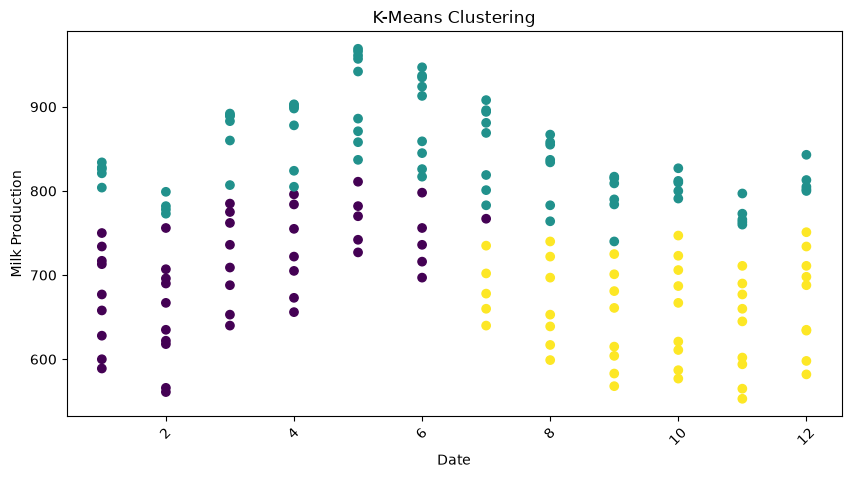


Final Results:
     Month  pounds per cow  Cluster  NLP_Cluster
0        1             589        0            1
1        2             561        0            1
2        3             640        0            1
3        4             656        0            1
4        5             727        0            1
..     ...             ...      ...          ...
163      8             858        1            2
164      9             817        1            2
165     10             827        1            2
166     11             797        1            2
167     12             843        1            2

[168 rows x 4 columns]

Saved as milk_production_clusters.csv


In [2]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score

# 2. Load dataset
df = pd.read_csv("monthly-milk-production.csv")

print(df.head())
print(df.info())

# 3. Clean data
df = df.dropna()

# Automatically use first two columns
date_col = df.columns[0]
milk_col = df.columns[1]

df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df[milk_col] = pd.to_numeric(df[milk_col], errors="coerce")
df = df.dropna()

# 4. Create date features
df["Year"] = df[date_col].dt.year
df["Month"] = df[date_col].dt.month

# 5. K-Means clustering
X = df[["Year", "Month", milk_col]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print(df[[date_col, milk_col, "Cluster"]])

# 6. Silhouette score
print("Silhouette Score:",
      silhouette_score(X_scaled, df["Cluster"]))

# 7. Plot K-Means clusters
plt.figure(figsize=(10,5))
plt.scatter(df[date_col], df[milk_col], c=df["Cluster"])
plt.xlabel("Date")
plt.ylabel("Milk Production")
plt.title("K-Means Clustering")
plt.xticks(rotation=45)
plt.show()

# 8. NLP - convert records to text
df["Text"] = (
    "year " + df["Year"].astype(str) +
    " month " + df["Month"].astype(str) +
    " milk production " + df[milk_col].astype(str)
)

# 9. TF-IDF
tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(df["Text"])

# 10. K-Means with NLP features
nlp_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["NLP_Cluster"] = nlp_kmeans.fit_predict(X_text)

# 11. Results
print("\nFinal Results:")
print(df[[date_col, milk_col, "Cluster", "NLP_Cluster"]])

# 12. Save dataset
df.to_csv("milk_production_clusters.csv", index=False)

print("\nSaved as milk_production_clusters.csv")